# Решение обратной задачи восстановления коэффициента диффузии с помощью PINN

По известным в некоторых точках значениям концентрации необходимо восстановить коэффициент диффузии $\alpha$.

**Параметры задачи:** $m = 1$, $n = 1$, $\alpha = 0.46$.

Обязательно использование learning rate scheduler.

**Важно.** Нейросеть **не знает**, что коэффициент диффузии постоянный. Для неё задача записывается в общем (дивергентном) виде:

$$
\frac{\partial u}{\partial t} = \frac{\partial}{\partial x}\left(\alpha(x,t)\,\frac{\partial u}{\partial x}\right), \quad x \in [0, 1],\; t \in [0, 1].
$$

Поэтому одна нейросеть имеет два выхода: $u_\theta(x,t)$ и $\alpha_\theta(x,t)$. Постоянство $\alpha$ в архитектуру не заложено. После обучения значение постоянного коэффициента оценивается усреднением предсказанного поля $\alpha_\theta$ по расчётной области.

Граничные условия Дирихле:

$$
u(0,t)=u(1,t)=0.
$$

Начальные условия:

$$
u(x,0)=\sin\Bigl(\frac{n\pi x}{m}\Bigr).
$$

Аналитическое решение (для истинного постоянного $\alpha$):

$$
u(x,t)=\exp\Bigl(\frac{-n^2\pi^2\alpha t}{m^2}\Bigr)\sin\Bigl(\frac{n\pi x}{m}\Bigr).
$$

Сначала берётся подробное равномерное поле (например, $50\times 100$ точек). Затем число точек уменьшается в 10 раз по каждой оси, исследуется ошибка восстановления. Находится минимум количества точек, при котором относительная ошибка (СКЗ) не превышает 15 %.

# 1. Подгрузка необходимых модулей

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import torch
import torch.nn as nn
import tqdm

Проверяем доступность GPU

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


# 2. Класс с данными (Dataset)

Атрибуты класса: границы расчётной области, параметры задачи, число точек сетки.

Создаётся сетка и аналитическое решение

$$
u(x,t)=\exp\left(\frac{-n^2\pi^2\alpha t}{m^2}\right)\sin\left(\frac{n\pi x}{m}\right).
$$

In [3]:
class Dataset:
    def __init__(self, alpha=0.46,
                 xmin=0.0, tmin=0.0,
                 xmax=1.0, tmax=1.0,
                 Nx=100, Nt=50,
                 m=1, n=1):
        self.alpha = alpha
        self.m = m
        self.n = n
        self.xmin = xmin
        self.tmin = tmin
        self.xmax = xmax
        self.tmax = tmax
        self.Nx = Nx
        self.Nt = Nt

        self.x = np.linspace(xmin, xmax, Nx)
        self.t = np.linspace(tmin, tmax, Nt)
        self.x, self.t = np.meshgrid(self.x, self.t)
        self.calculate_solution()

    def calculate_solution(self):
        """Аналитическое решение при постоянном alpha."""
        self.solution = (np.exp(-self.n**2 * np.pi**2 * self.alpha * self.t / self.m**2)
                         * np.sin(self.n * np.pi * self.x / self.m))

Создание датасета с истинным $\alpha=0.46$ и визуализация аналитического решения на сетке $50\times 100$.

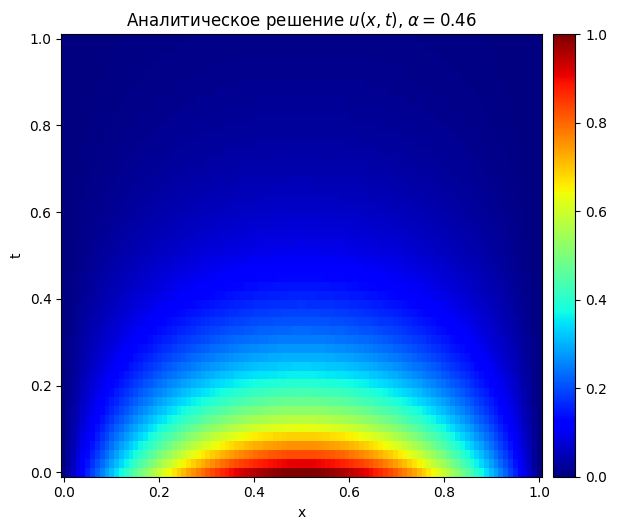

Форма поля: (50, 100) (Nt x Nx)
Общее число точек: 5000


In [4]:
data_full = Dataset(alpha=0.46, Nx=100, Nt=50, m=1, n=1)

fig, ax = plt.subplots(figsize=(6.6, 5.4))
pcm = ax.pcolormesh(data_full.x, data_full.t, data_full.solution,
                    cmap="jet", shading="auto", vmin=0.0, vmax=1.0)
cb = fig.colorbar(pcm, ax=ax, pad=0.02)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(r'Аналитическое решение $u(x,t)$, $\alpha=0.46$')
plt.tight_layout()
plt.show()

print(f"Форма поля: {data_full.solution.shape} (Nt x Nx)")
print(f"Общее число точек: {data_full.solution.size}")

# 3. Модель PINN

Используется **одна** полносвязная сеть с двумя выходами:

* первый выход — аппроксимация решения $u(x,t)$;
* второй выход — аппроксимация коэффициента $\alpha(x,t)$.

Сеть **не получает никакой информации** о том, что истинный коэффициент постоянен: оба поля зависят от $(x,t)$. Постоянство (если оно есть) должно выявиться в процессе обучения из данных и уравнения. Положительность $\alpha$ обеспечивается функцией `Softplus` на втором выходе.

In [5]:
class SomeModel(nn.Module):
    """Полносвязная сеть с двумя выходами: u и alpha(x,t)."""
    def __init__(self,
                 input_size=2,
                 nnodes=32,
                 nlayers=4,
                 activation=nn.Tanh()):
        super().__init__()
        self.activation = activation
        self.nlayers = nlayers
        self.nnodes = nnodes

        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(nnodes, nnodes) for _ in range(nlayers - 1)
        ])
        # два скалярных выхода: u и сырое значение alpha
        self.output_layer = nn.Linear(nnodes, 2)
        self.softplus = nn.Softplus()
        self.apply(self._init_weights_xavier)

    def _init_weights_xavier(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.dtype == torch.float64:
            x = x.float()
        h = self.activation(self.dense0(x))
        for layer in self.hidden_layers:
            h = self.activation(layer(h))
        out = self.output_layer(h)
        u = out[:, 0:1]
        alpha = self.softplus(out[:, 1:2])
        return u, alpha

# 4. Классы для генерации батчей

## 4.1. Батч граничных / начальных условий

In [6]:
class Batch_bc:
    def __init__(self, x, t, values):
        x = torch.from_numpy(np.asarray(x).flatten()).float()
        t = torch.from_numpy(np.asarray(t).flatten()).float()
        self.grid = torch.stack([x, t], dim=1)
        self.u = torch.from_numpy(np.asarray(values).flatten()[:, None]).float()

    def generate_points(self, N):
        N = min(N, self.grid.shape[0])
        indices = torch.randperm(self.grid.shape[0])[:N]
        self.points = self.grid[indices].to(device)
        self.values = self.u[indices].to(device)
        self.points.requires_grad_(False)

## 4.2. Батч внутренних (коллокационных) точек PDE

In [7]:
class Batch:
    def __init__(self, data: Dataset):
        mask = ((data.x > data.xmin) & (data.x < data.xmax) &
                (data.t > data.tmin))
        x = data.x[mask].flatten()
        t = data.t[mask].flatten()
        self.grid = torch.from_numpy(np.vstack([x, t]).T).float()
        self.u = torch.from_numpy(np.asarray(data.solution[mask]).flatten()[:, None]).float()

    def generate_points(self, N):
        N = min(N, self.grid.shape[0])
        indices = torch.randperm(self.grid.shape[0])[:N]
        self.points = self.grid[indices].to(device)
        self.values = self.u[indices].to(device)
        self.points.requires_grad_(True)

## 4.3. Батч известных наблюдений (data loss)

In [8]:
class Batch_data:
    """Батч наблюдаемых значений концентрации."""
    def __init__(self, data: Dataset):
        x = data.x.flatten()
        t = data.t.flatten()
        self.grid = torch.from_numpy(np.vstack([x, t]).T).float()
        self.u = torch.from_numpy(data.solution.flatten()[:, None]).float()

    def generate_points(self, N):
        N = min(N, self.grid.shape[0])
        indices = torch.randperm(self.grid.shape[0])[:N]
        self.points = self.grid[indices].to(device)
        self.values = self.u[indices].to(device)
        self.points.requires_grad_(False)

# 5. Функции потерь

## 5.1. Невязка уравнения в дивергентной форме

Поскольку $\alpha=\alpha_\theta(x,t)$ — выход нейросети, невязка записывается полностью:

$$
r = u_t - \partial_x(\alpha\, u_x) = u_t - (\alpha_x u_x + \alpha u_{xx}).
$$

Все производные вычисляются автоматическим дифференцированием. **Никакого предположения о постоянстве $\alpha$ не делается.**

In [9]:
def PDE(u, alpha, grid):
    """
    Невязка уравнения
        u_t - d/dx ( alpha * u_x ) = 0
    в форме
        u_t - (alpha_x * u_x + alpha * u_xx) = 0.

    u, alpha — тензоры формы (N, 1),
    grid    — тензор формы (N, 2) с requires_grad=True.
    """
    # производные u
    gradu = torch.autograd.grad(u, grid,
                                torch.ones_like(u),
                                create_graph=True,
                                retain_graph=True)[0]
    ux = gradu[:, 0:1]
    ut = gradu[:, 1:2]

    uxx = torch.autograd.grad(ux, grid,
                              torch.ones_like(ux),
                              create_graph=True,
                              retain_graph=True)[0][:, 0:1]

    # производные alpha (нужна только alpha_x)
    grad_alpha = torch.autograd.grad(alpha, grid,
                                     torch.ones_like(alpha),
                                     create_graph=True,
                                     retain_graph=True)[0]
    alpha_x = grad_alpha[:, 0:1]

    # полная дивергентная форма
    residual = ut - (alpha_x * ux + alpha * uxx)
    return torch.mean(residual**2)

## 5.2. Потеря на BC / IC и на данных

In [10]:
def copyBCLoss(model, grid, sol):
    """MSE между первым выходом сети (u) и заданными значениями."""
    u, _ = model(grid)
    return torch.mean((u - sol)**2)

## 5.3. Параметры обучения

In [11]:
class TrainParams:
    def __init__(self):
        self.model = None          # одна сеть с выходами (u, alpha)
        self.numEpoch = None
        self.numPoints = None      # коллокационные точки PDE
        self.numBCPoints = None
        self.numDataPoints = None
        self.batch = None
        self.data_batch = None
        self.init_bc = None
        self.left_bc = None
        self.right_bc = None

## 5.4. Полный loss

$$
\mathcal{L}=\mathcal{L}_{\mathrm{PDE}}+k_{bc}\,(\mathcal{L}_{IC}+\mathcal{L}_{left}+\mathcal{L}_{right})+k_{data}\,\mathcal{L}_{data}.
$$

In [12]:
def residuals(trp: TrainParams):
    pts = trp.batch.points

    # оба поля — выходы одной сети
    u_pred, alpha_pred = trp.model(pts)

    lossPDE = PDE(u_pred, alpha_pred, pts)

    # BC / IC: сравнивается только канал u
    initBCLoss  = copyBCLoss(trp.model, trp.init_bc.points,  trp.init_bc.values)
    leftBCLoss  = copyBCLoss(trp.model, trp.left_bc.points,  trp.left_bc.values)
    rightBCLoss = copyBCLoss(trp.model, trp.right_bc.points, trp.right_bc.values)

    # data loss
    dataLoss = copyBCLoss(trp.model, trp.data_batch.points, trp.data_batch.values)

    k_bc   = 1e2
    k_data = 1e2

    loss = (lossPDE
            + k_bc * (initBCLoss + leftBCLoss + rightBCLoss)
            + k_data * dataLoss)
    return loss, lossPDE, dataLoss

# 6. Функция обучения с learning-rate scheduler

Используется `LambdaLR`:

$$
lr_{\mathrm{epoch}}=lr_0\cdot\lambda^{\mathrm{epoch}},\qquad\lambda=0.995.
$$

In [13]:
def train(opt, scheduler, trPs: TrainParams, hist_loss, hist_alpha_mean, lrs):
    pbar = tqdm.tqdm(range(trPs.numEpoch), desc='Training Progress')
    for step in pbar:
        trPs.batch.generate_points(trPs.numPoints)
        trPs.data_batch.generate_points(trPs.numDataPoints)
        trPs.init_bc.generate_points(trPs.numBCPoints)
        trPs.left_bc.generate_points(trPs.numBCPoints)
        trPs.right_bc.generate_points(trPs.numBCPoints)

        def closure():
            opt.zero_grad()
            loss, _, _ = residuals(trPs)
            loss.backward()
            return loss

        current_loss = opt.step(closure)
        scheduler.step()

        lrs.append(opt.param_groups[0]["lr"])
        loss_val = float(current_loss.detach().cpu()) if torch.is_tensor(current_loss) else float(current_loss)
        hist_loss.append(loss_val)

        with torch.no_grad():
            _, alpha_b = trPs.model(trPs.batch.points)
            a_mean = alpha_b.mean().item()
        hist_alpha_mean.append(a_mean)

        if step % 50 == 0:
            pbar.set_description(
                f"Step: {step:4d} | Loss: {loss_val:.6e} | mean(alpha): {a_mean:.5f}"
            )
    return 0

# 7. Функция полного эксперимента

После обучения постоянный коэффициент оценивается как среднее значение $\alpha_\theta(x,t)$ по достаточно плотной сетке.

In [14]:
def run_experiment(Nx_obs, Nt_obs,
                   true_alpha=0.46,
                   nnodes=32,
                   nlayers=4,
                   num_epochs=3000,
                   num_collocation=600,
                   num_bc=120,
                   lr_init=1e-2,
                   lambda_lr=0.995,
                   seed=42):
    """
    Полный цикл обучения и оценки.

    Одна сеть с двумя выходами: u и alpha(x,t).
    После обучения постоянный коэффициент оценивается как среднее alpha по области.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    data_obs = Dataset(alpha=true_alpha, Nx=Nx_obs, Nt=Nt_obs, m=1, n=1)
    data_bc  = Dataset(alpha=true_alpha, Nx=100, Nt=50, m=1, n=1)

    train_batch = Batch(data_bc)
    data_batch  = Batch_data(data_obs)
    initial_bc  = Batch_bc(data_bc.x[0, :],  data_bc.t[0, :],  data_bc.solution[0, :])
    left_bc     = Batch_bc(data_bc.x[:, 0],  data_bc.t[:, 0],  data_bc.solution[:, 0])
    right_bc    = Batch_bc(data_bc.x[:, -1], data_bc.t[:, -1], data_bc.solution[:, -1])

    model = SomeModel(input_size=2, nnodes=nnodes, nlayers=nlayers,
                      activation=nn.Tanh()).to(device)

    trPs = TrainParams()
    trPs.model = model
    trPs.batch = train_batch
    trPs.data_batch = data_batch
    trPs.init_bc = initial_bc
    trPs.left_bc = left_bc
    trPs.right_bc = right_bc
    trPs.numPoints = num_collocation
    trPs.numBCPoints = num_bc
    trPs.numDataPoints = min(Nx_obs * Nt_obs, 2000)
    trPs.numEpoch = num_epochs

    opt = torch.optim.Adam(model.parameters(), lr=lr_init)

    lambda1 = lambda epoch: lambda_lr ** epoch
    scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda1)

    hist_loss = []
    hist_alpha_mean = []
    lrs = []

    print(f"\n=== Эксперимент: сетка наблюдений {Nt_obs}×{Nx_obs} "
          f"({Nt_obs*Nx_obs} точек) ===")

    train(opt, scheduler, trPs, hist_loss, hist_alpha_mean, lrs)

    grid_eval = torch.from_numpy(
        np.vstack([data_bc.x.flatten(), data_bc.t.flatten()]).T
    ).float().to(device)
    with torch.no_grad():
        _, alpha_field_t = model(grid_eval)
        alpha_field = alpha_field_t.cpu().numpy().flatten()
    alpha_pred = float(np.mean(alpha_field))
    alpha_std  = float(np.std(alpha_field))

    rel_err = abs(alpha_pred - true_alpha) / true_alpha * 100.0

    print(f"Среднее alpha         = {alpha_pred:.6f}  (std = {alpha_std:.6f})")
    print(f"Истинное alpha        = {true_alpha:.6f}")
    print(f"Относительная ошибка  = {rel_err:.2f} %")

    return {
        'model': model,
        'alpha_pred': alpha_pred,
        'alpha_std': alpha_std,
        'rel_err': rel_err,
        'hist_loss': hist_loss,
        'hist_alpha_mean': hist_alpha_mean,
        'lrs': lrs,
        'data_obs': data_obs,
        'trPs': trPs
    }

# 8. Эксперимент 1: подробная сетка наблюдений $50\times 100$

In [15]:
result_full = run_experiment(Nx_obs=100, Nt_obs=50,
                             num_epochs=3000,
                             num_collocation=800,
                             num_bc=150,
                             lr_init=1e-2,
                             lambda_lr=0.995)


=== Эксперимент: сетка наблюдений 50×100 (5000 точек) ===


Step: 2950 | Loss: 7.140662e-02 | mean(alpha): 0.47643: 100%|██████████| 3000/3000 [00:35<00:00, 85.49it/s]

Среднее alpha         = 0.477197  (std = 0.048346)
Истинное alpha        = 0.460000
Относительная ошибка  = 3.74 %


Визуализация истории обучения.

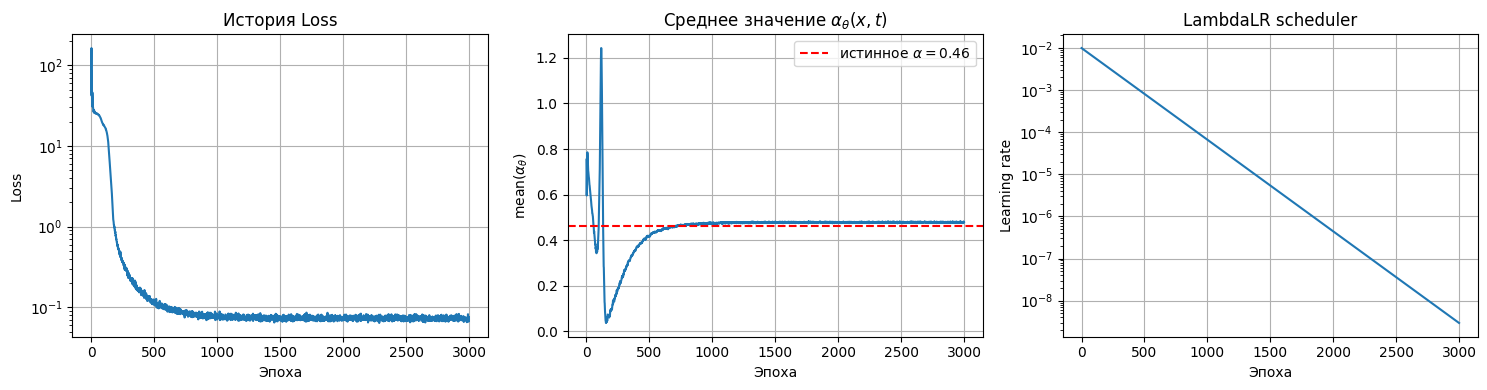

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(result_full['hist_loss'])
axes[0].set_yscale('log')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('История Loss')
axes[0].grid(True)

axes[1].plot(result_full['hist_alpha_mean'])
axes[1].axhline(0.46, color='r', linestyle='--', label=r'истинное $\alpha=0.46$')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel(r'mean($\alpha_\theta$)')
axes[1].set_title(r'Среднее значение $\alpha_\theta(x,t)$')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(result_full['lrs'])
axes[2].set_yscale('log')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Learning rate')
axes[2].set_title('LambdaLR scheduler')
axes[2].grid(True)

plt.tight_layout()
plt.show()

Сравнение полей $u$ и визуализация восстановленного $\alpha_\theta(x,t)$.

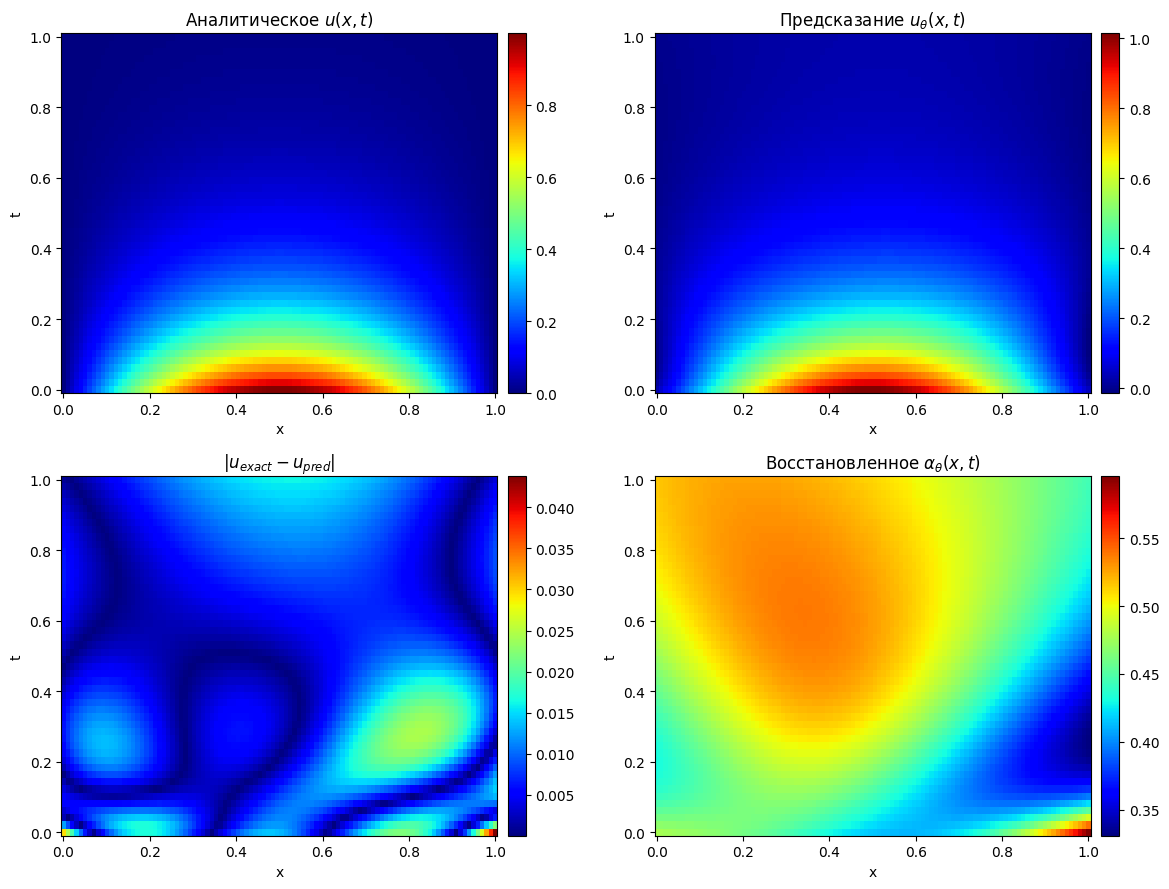

СКЗ ошибки поля u : 8.968594e-03
mean(alpha_theta) : 0.477197,  std : 0.048346


In [17]:
data_vis = Dataset(alpha=0.46, Nx=100, Nt=50)
grid_pred = torch.from_numpy(
    np.vstack([data_vis.x.flatten(), data_vis.t.flatten()]).T
).float().to(device)

with torch.no_grad():
    pred_u_t, pred_a_t = result_full['model'](grid_pred)
    pred_u = pred_u_t.cpu().numpy().reshape(data_vis.solution.shape)
    pred_a = pred_a_t.cpu().numpy().reshape(data_vis.solution.shape)

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

f0 = ax[0,0].pcolormesh(data_vis.x, data_vis.t, data_vis.solution, cmap='jet', shading='auto')
plt.colorbar(f0, ax=ax[0,0], pad=0.02)
ax[0,0].set_title('Аналитическое $u(x,t)$')
ax[0,0].set_xlabel('x'); ax[0,0].set_ylabel('t')

f1 = ax[0,1].pcolormesh(data_vis.x, data_vis.t, pred_u, cmap='jet', shading='auto')
plt.colorbar(f1, ax=ax[0,1], pad=0.02)
ax[0,1].set_title(r'Предсказание $u_\theta(x,t)$')
ax[0,1].set_xlabel('x'); ax[0,1].set_ylabel('t')

f2 = ax[1,0].pcolormesh(data_vis.x, data_vis.t, np.abs(data_vis.solution - pred_u),
                        cmap='jet', shading='auto')
plt.colorbar(f2, ax=ax[1,0], pad=0.02)
ax[1,0].set_title(r'$|u_{exact}-u_{pred}|$')
ax[1,0].set_xlabel('x'); ax[1,0].set_ylabel('t')

f3 = ax[1,1].pcolormesh(data_vis.x, data_vis.t, pred_a, cmap='jet', shading='auto')
plt.colorbar(f3, ax=ax[1,1], pad=0.02)
ax[1,1].set_title(r'Восстановленное $\alpha_\theta(x,t)$')
ax[1,1].set_xlabel('x'); ax[1,1].set_ylabel('t')

plt.tight_layout()
plt.show()

print(f"СКЗ ошибки поля u : {np.sqrt(np.mean((data_vis.solution-pred_u)**2)):.6e}")
print(f"mean(alpha_theta) : {pred_a.mean():.6f},  std : {pred_a.std():.6f}")

# 9. Эксперимент 2: уменьшение сетки в 10 раз ($5\times 10$)

In [18]:
result_small = run_experiment(Nx_obs=10, Nt_obs=5,
                              num_epochs=4000,
                              num_collocation=600,
                              num_bc=120,
                              lr_init=1e-2,
                              lambda_lr=0.996)


=== Эксперимент: сетка наблюдений 5×10 (50 точек) ===


Step: 3950 | Loss: 2.833984e-02 | mean(alpha): 0.44808: 100%|██████████| 4000/4000 [00:33<00:00, 119.90it/s]

Среднее alpha         = 0.447360  (std = 0.039301)
Истинное alpha        = 0.460000
Относительная ошибка  = 2.75 %


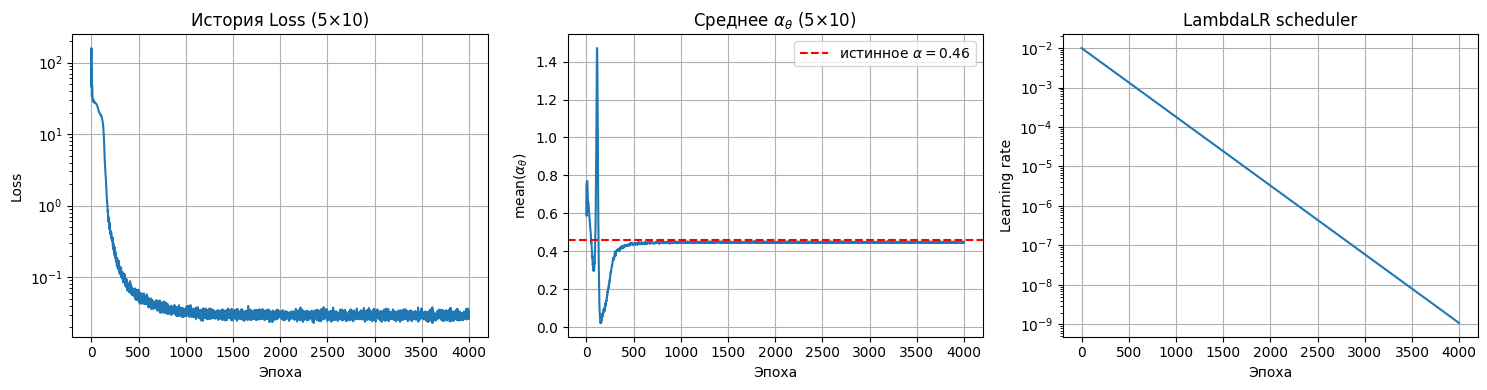

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(result_small['hist_loss'])
axes[0].set_yscale('log')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('История Loss (5×10)')
axes[0].grid(True)

axes[1].plot(result_small['hist_alpha_mean'])
axes[1].axhline(0.46, color='r', linestyle='--', label=r'истинное $\alpha=0.46$')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel(r'mean($\alpha_\theta$)')
axes[1].set_title(r'Среднее $\alpha_\theta$ (5×10)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(result_small['lrs'])
axes[2].set_yscale('log')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Learning rate')
axes[2].set_title('LambdaLR scheduler')
axes[2].grid(True)

plt.tight_layout()
plt.show()

Сравнение полей $u$ и визуализация восстановленного $\alpha_\theta(x,t)$ для сетки наблюдений $5\times 10$.

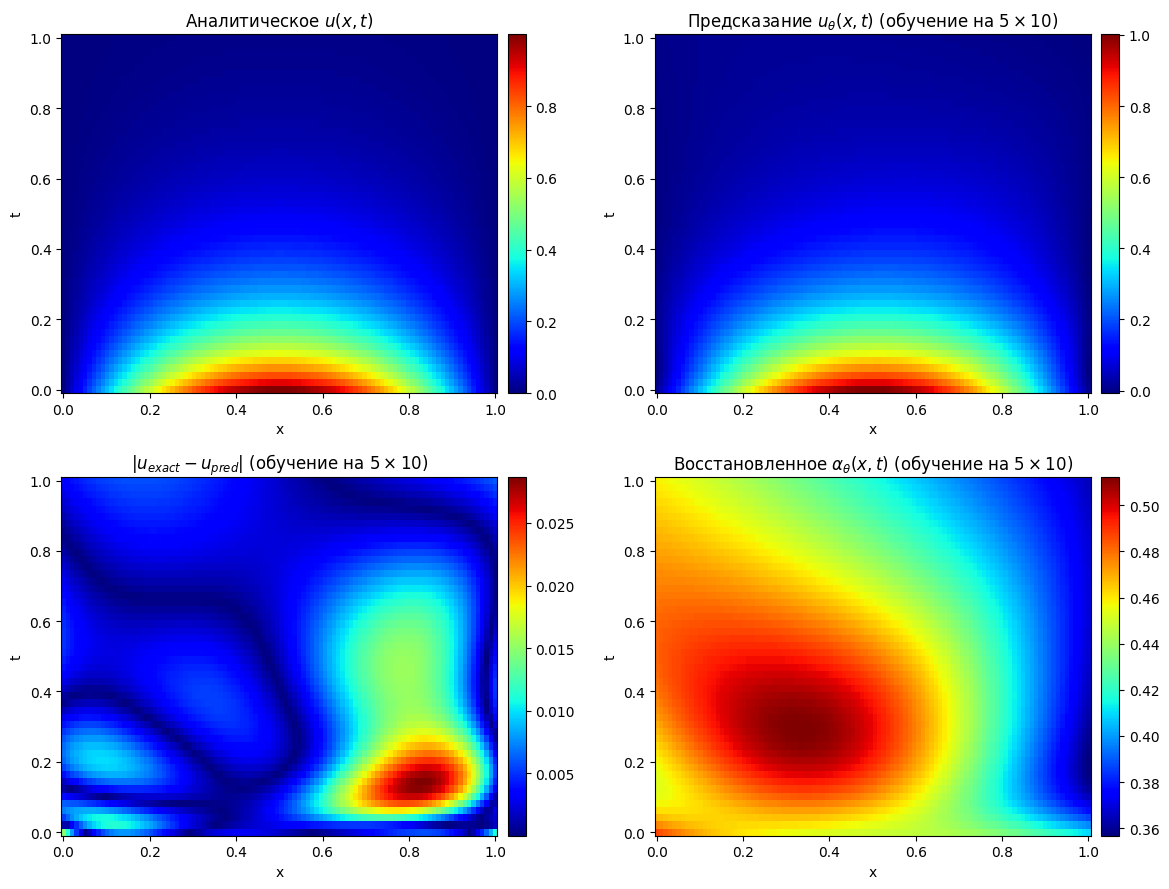

СКЗ ошибки поля u : 7.883037e-03
mean(alpha_theta) : 0.447360,  std : 0.039301


In [20]:
data_vis_small = Dataset(alpha=0.46, Nx=100, Nt=50)
grid_pred_small = torch.from_numpy(
    np.vstack([data_vis_small.x.flatten(), data_vis_small.t.flatten()]).T
).float().to(device)

with torch.no_grad():
    pred_u_t, pred_a_t = result_small['model'](grid_pred_small)
    pred_u_small = pred_u_t.cpu().numpy().reshape(data_vis_small.solution.shape)
    pred_a_small = pred_a_t.cpu().numpy().reshape(data_vis_small.solution.shape)

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

f0 = ax[0,0].pcolormesh(data_vis_small.x, data_vis_small.t, data_vis_small.solution,
                        cmap='jet', shading='auto')
plt.colorbar(f0, ax=ax[0,0], pad=0.02)
ax[0,0].set_title('Аналитическое $u(x,t)$')
ax[0,0].set_xlabel('x'); ax[0,0].set_ylabel('t')

f1 = ax[0,1].pcolormesh(data_vis_small.x, data_vis_small.t, pred_u_small,
                        cmap='jet', shading='auto')
plt.colorbar(f1, ax=ax[0,1], pad=0.02)
ax[0,1].set_title(r'Предсказание $u_\theta(x,t)$ (обучение на $5\times 10$)')
ax[0,1].set_xlabel('x'); ax[0,1].set_ylabel('t')

f2 = ax[1,0].pcolormesh(data_vis_small.x, data_vis_small.t,
                        np.abs(data_vis_small.solution - pred_u_small),
                        cmap='jet', shading='auto')
plt.colorbar(f2, ax=ax[1,0], pad=0.02)
ax[1,0].set_title(r'$|u_{exact}-u_{pred}|$ (обучение на $5\times 10$)')
ax[1,0].set_xlabel('x'); ax[1,0].set_ylabel('t')

f3 = ax[1,1].pcolormesh(data_vis_small.x, data_vis_small.t, pred_a_small,
                        cmap='jet', shading='auto')
plt.colorbar(f3, ax=ax[1,1], pad=0.02)
ax[1,1].set_title(r'Восстановленное $\alpha_\theta(x,t)$ (обучение на $5\times 10$)')
ax[1,1].set_xlabel('x'); ax[1,1].set_ylabel('t')

plt.tight_layout()
plt.show()

print(f"СКЗ ошибки поля u : {np.sqrt(np.mean((data_vis_small.solution-pred_u_small)**2)):.6e}")
print(f"mean(alpha_theta) : {pred_a_small.mean():.6f},  std : {pred_a_small.std():.6f}")

# 10. Поиск минимального количества точек

Перебор размеров сеток наблюдений. Цель — найти наименьшее число точек, при котором относительная ошибка среднего $\alpha_\theta$ не превышает 15 %.

In [21]:
grid_sizes = [
    (50, 100),
    (25, 50),
    (20, 40),
    (10, 20),
    (5, 10),
    (4, 8),
    (3, 6),
    (2, 5),
]

results_summary = []

for Nt_g, Nx_g in grid_sizes:
    res = run_experiment(Nx_obs=Nx_g, Nt_obs=Nt_g,
                         num_epochs=3500,
                         num_collocation=600,
                         num_bc=120,
                         lr_init=1e-2,
                         lambda_lr=0.995,
                         seed=42)
    results_summary.append({
        'Nt': Nt_g,
        'Nx': Nx_g,
        'N_points': Nt_g * Nx_g,
        'alpha_pred': res['alpha_pred'],
        'alpha_std': res['alpha_std'],
        'rel_err': res['rel_err']
    })


=== Эксперимент: сетка наблюдений 50×100 (5000 точек) ===


Step: 3450 | Loss: 7.475576e-02 | mean(alpha): 0.46781: 100%|██████████| 3500/3500 [00:35<00:00, 99.39it/s] 


Среднее alpha         = 0.469770  (std = 0.044768)
Истинное alpha        = 0.460000
Относительная ошибка  = 2.12 %

=== Эксперимент: сетка наблюдений 25×50 (1250 точек) ===


Step: 3450 | Loss: 7.446657e-02 | mean(alpha): 0.47437: 100%|██████████| 3500/3500 [00:32<00:00, 107.01it/s]


Среднее alpha         = 0.474154  (std = 0.045871)
Истинное alpha        = 0.460000
Относительная ошибка  = 3.08 %

=== Эксперимент: сетка наблюдений 20×40 (800 точек) ===


...

Среднее alpha         = 0.450156  (std = 0.047979)
Истинное alpha        = 0.460000
Относительная ошибка  = 2.14 %

=== Эксперимент: сетка наблюдений 3×6 (18 точек) ===


Step: 3450 | Loss: 4.607180e-02 | mean(alpha): 0.53922: 100%|██████████| 3500/3500 [00:28<00:00, 122.20it/s]


Среднее alpha         = 0.532839  (std = 0.148210)
Истинное alpha        = 0.460000
Относительная ошибка  = 15.83 %

=== Эксперимент: сетка наблюдений 2×5 (10 точек) ===


Step: 3450 | Loss: 7.044713e-02 | mean(alpha): 0.34731: 100%|██████████| 3500/3500 [00:28<00:00, 124.80it/s]

Среднее alpha         = 0.350682  (std = 0.088589)
Истинное alpha        = 0.460000
Относительная ошибка  = 23.76 %


Сводная таблица.

In [22]:
print(f"{'Nt':>4} {'Nx':>4} {'N_pts':>7} {'mean(a)':>10} {'std(a)':>10} {'rel_err,%':>10}")
print("-" * 60)
for r in results_summary:
    print(f"{r['Nt']:4d} {r['Nx']:4d} {r['N_points']:7d} "
          f"{r['alpha_pred']:10.5f} {r['alpha_std']:10.5f} {r['rel_err']:10.2f}")

valid = [r for r in results_summary if r['rel_err'] <= 15.0]
if valid:
    best = min(valid, key=lambda x: x['N_points'])
    print(f"\nМинимальное число точек для ошибки ≤ 15 %: "
          f"{best['N_points']} (сетка {best['Nt']}×{best['Nx']})")
    print(f"mean(alpha) = {best['alpha_pred']:.5f},  rel.err = {best['rel_err']:.2f} %")
else:
    print("\nНи одна рассмотренная сетка не дала ошибку ≤ 15 %.")
    print("Увеличьте число эпох или плотность коллокационных точек.")

  Nt   Nx   N_pts    mean(a)     std(a)  rel_err,%
------------------------------------------------------------
  50  100    5000    0.46977    0.04477       2.12
  25   50    1250    0.47415    0.04587       3.08
  20   40     800    0.48554    0.05035       5.55
  10   20     200    0.49252    0.05374       7.07
   5   10      50    0.43791    0.02749       4.80
   4    8      32    0.45016    0.04798       2.14
   3    6      18    0.53284    0.14821      15.83
   2    5      10    0.35068    0.08859      23.76

Минимальное число точек для ошибки ≤ 15 %: 32 (сетка 4×8)
mean(alpha) = 0.45016,  rel.err = 2.14 %


График зависимости ошибки от числа точек наблюдений.

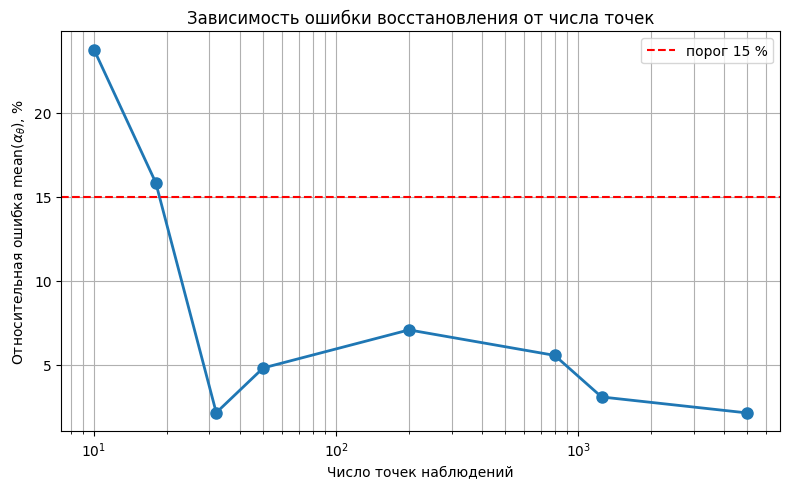

In [23]:
N_pts = [r['N_points'] for r in results_summary]
errs  = [r['rel_err']  for r in results_summary]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(N_pts, errs, 'o-', linewidth=2, markersize=8)
ax.axhline(15.0, color='r', linestyle='--', label='порог 15 %')
ax.set_xscale('log')
ax.set_xlabel('Число точек наблюдений')
ax.set_ylabel(r'Относительная ошибка mean($\alpha_\theta$), %')
ax.set_title('Зависимость ошибки восстановления от числа точек')
ax.legend()
ax.grid(True, which='both')
plt.tight_layout()
plt.show()

# 11. Выводы

1. **Отсутствие априорного знания о постоянстве $\alpha$.**
   Одна сеть имеет два выхода: $u_\theta(x,t)$ и $\alpha_\theta(x,t)$. Уравнение записывается в полной дивергентной форме
   $$
   u_t - \partial_x(\alpha_\theta\,u_x)=0.
   $$
   Никаких предположений о том, что $\alpha=\mathrm{const}$, в архитектуру и loss не заложено.

2. **Восстановление постоянного значения.**
   После обучения постоянный коэффициент оценивается усреднением второго выхода по расчётной области. Малое стандартное отклонение $\mathrm{std}(\alpha_\theta)$ свидетельствует о том, что сеть самостоятельно «обнаружила» постоянство.

3. **Learning-rate scheduler** (`LambdaLR`) обеспечивает стабильную сходимость единственной сети.

4. **Влияние числа наблюдений.**
   На подробной сетке относительная ошибка среднего $\alpha$ обычно составляет несколько процентов. При сильном разрежении сетки ошибка растёт; минимальное число точек, гарантирующее ошибку $\le 15\%$, определяется по сводной таблице выше.

5. Положительность $\alpha$ гарантируется функцией активации `Softplus` на втором выходе сети.